# 📊 ETL Supermercado — Análise Estatística e Visualizações

Este notebook apresenta as principais estatísticas do projeto **ETL Supermercado**, utilizando a base tratada `data/processed/vendas_tratadas.csv`.

As análises reproduzem as métricas do arquivo `src/_03_estatistica.py` e acrescentam visualizações para facilitar a interpretação dos resultados.

### Análises apresentadas

- Receita total por filial;
- Quantidade de vendas por filial;
- Receita por linha de produto;
- Avaliação média por linha de produto;
- Formas de pagamento;
- Valor médio das vendas;
- Maior venda;
- Vendas por dia da semana;
- Distribuição dos valores das vendas;
- Resumo geral dos principais indicadores.

> **Pré-requisito:** execute este notebook a partir da raiz do projeto `ETL_Supermercado`, onde existe a pasta `data/processed/`.


## Importação das bibliotecas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

arquivo_csv_vendas_tratadas = Path("../data/processed/vendas_tratadas.csv")

df = pd.read_csv(arquivo_csv_vendas_tratadas)

print("Base carregada com sucesso!")
print(f"Total de registros: {len(df):,}")


Base carregada com sucesso!
Total de registros: 1,000


## Visão geral da base

In [7]:
display(df.head())

print("\nTipos de dados:")
display(df.dtypes)

print("\nValores nulos por coluna:")
display(df.isna().sum())


,id_venda,filial,cidade,tipo_cliente,genero,linha_produto,preco_unitario,quantidade,imposto,valor_total,data_venda,hora_venda,forma_pagamento,custo_mercadoria,margem_percentual,receita_bruta,avaliacao
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.14,548.97,2019-01-05,13:08:00,Ewallet,522.83,4.76,26.14,9.10
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.82,80.22,2019-03-08,10:29:00,Cash,76.40,4.76,3.82,9.60
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.22,340.53,2019-03-03,13:23:00,Credit card,324.31,4.76,16.22,7.40
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.29,489.05,2019-01-27,20:33:00,Ewallet,465.76,4.76,23.29,8.40
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.21,634.38,2019-02-08,10:37:00,Ewallet,604.17,4.76,30.21,5.30



Tipos de dados:


id_venda                 str
filial                   str
cidade                   str
tipo_cliente             str
genero                   str
linha_produto            str
preco_unitario       float64
quantidade             int64
imposto              float64
valor_total          float64
data_venda               str
hora_venda               str
forma_pagamento          str
custo_mercadoria     float64
margem_percentual    float64
receita_bruta        float64
avaliacao            float64
dtype: object


Valores nulos por coluna:


id_venda             0
filial               0
cidade               0
tipo_cliente         0
genero               0
linha_produto        0
preco_unitario       0
quantidade           0
imposto              0
valor_total          0
data_venda           0
hora_venda           0
forma_pagamento      0
custo_mercadoria     0
margem_percentual    0
receita_bruta        0
avaliacao            0
dtype: int64

## Preparação dos dados

In [8]:
# Conversão das colunas de data e hora
df["data_venda"] = pd.to_datetime(df["data_venda"], errors="coerce")

# Criar dia da semana
df["dia_semana"] = df["data_venda"].dt.day_name()

# Ordem cronológica dos dias da semana
ordem_dias = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

# Conversão de colunas numéricas
colunas_numericas = [
    "preco_unitario",
    "quantidade",
    "imposto",
    "valor_total",
    "custo_mercadoria",
    "margem_percentual",
    "receita_bruta",
    "avaliacao"
]

for coluna in colunas_numericas:
    df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id_venda           1000 non-null   str           
 1   filial             1000 non-null   str           
 2   cidade             1000 non-null   str           
 3   tipo_cliente       1000 non-null   str           
 4   genero             1000 non-null   str           
 5   linha_produto      1000 non-null   str           
 6   preco_unitario     1000 non-null   float64       
 7   quantidade         1000 non-null   int64         
 8   imposto            1000 non-null   float64       
 9   valor_total        1000 non-null   float64       
 10  data_venda         1000 non-null   datetime64[us]
 11  hora_venda         1000 non-null   str           
 12  forma_pagamento    1000 non-null   str           
 13  custo_mercadoria   1000 non-null   float64       
 14  margem_percentual  1

## Resumo dos principais KPIs

In [9]:
receita_total = df["valor_total"].sum()
valor_medio = df["valor_total"].mean()
quantidade_vendas = len(df)
quantidade_produtos = df["linha_produto"].nunique()
avaliacao_media = df["avaliacao"].mean()

receita_por_filial = df.groupby("filial")["valor_total"].sum().sort_values(ascending=False)
vendas_por_filial = df.groupby("filial").size().sort_values(ascending=False)

maior_receita_filial = receita_por_filial.idxmax()
maior_vendas_filial = vendas_por_filial.idxmax()
maior_venda = df.loc[df["valor_total"].idxmax()]

kpis = pd.DataFrame({
    "Indicador": [
        "Receita total",
        "Valor médio por venda",
        "Quantidade de vendas",
        "Linhas de produto",
        "Avaliação média",
        "Filial com maior receita",
        "Filial com mais vendas",
    ],
    "Valor": [
        f"R$ {receita_total:,.2f}",
        f"R$ {valor_medio:,.2f}",
        f"{quantidade_vendas:,}",
        f"{quantidade_produtos}",
        f"{avaliacao_media:.2f}",
        maior_receita_filial,
        maior_vendas_filial,
    ]
})

display(kpis)


,Indicador,Valor
0,Receita total,"R$ 322,967.43"
1,Valor médio por venda,R$ 322.97
2,Quantidade de vendas,"1,000"
3,Linhas de produto,6
4,Avaliação média,6.97
5,Filial com maior receita,Giza
6,Filial com mais vendas,Alex


## Receita total por filial

Esta análise identifica qual filial apresenta o maior faturamento.


,receita_total
filial,
Giza,"110,568.86"
Alex,"106,200.57"
Cairo,"106,198.00"


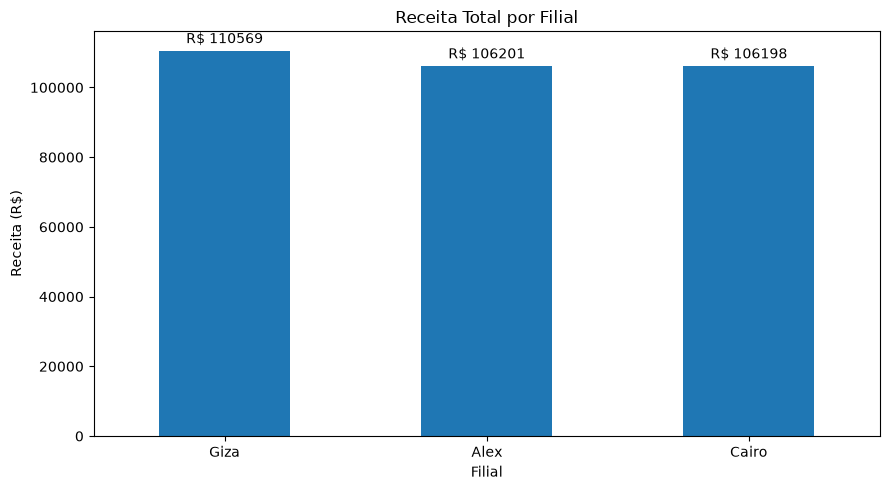

Maior receita: Giza — R$ 110,568.86


In [10]:
receita_por_filial = (
    df.groupby("filial")["valor_total"]
    .sum()
    .sort_values(ascending=False)
)

display(receita_por_filial.to_frame("receita_total"))

plt.figure(figsize=(9, 5))
ax = receita_por_filial.plot(kind="bar")
plt.title("Receita Total por Filial")
plt.xlabel("Filial")
plt.ylabel("Receita (R$)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="R$ %.0f", padding=3)

plt.tight_layout()
plt.show()

print(
    f"Maior receita: {receita_por_filial.idxmax()} "
    f"— R$ {receita_por_filial.max():,.2f}"
)


## Quantidade de vendas por filial

A quantidade de vendas mostra o volume de transações realizadas em cada filial.


,quantidade_vendas
filial,
Alex,340
Cairo,332
Giza,328


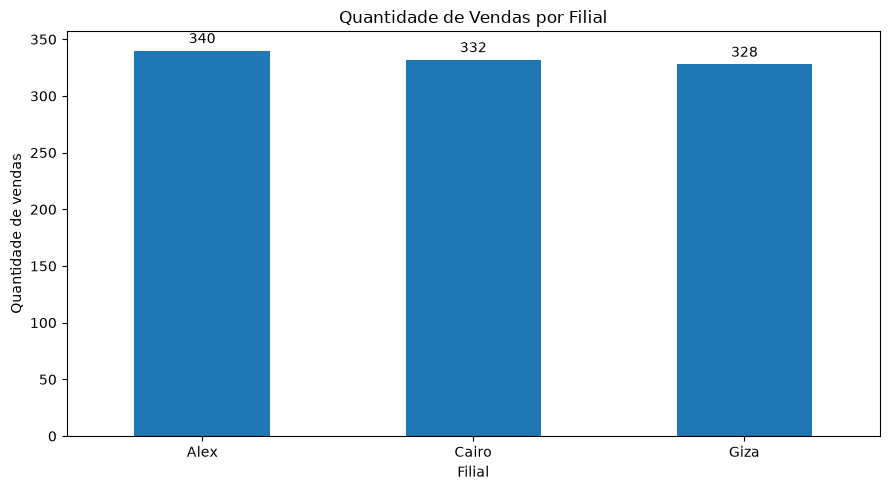

Filial com maior quantidade de vendas: Alex — 340 vendas


In [11]:
vendas_por_filial = (
    df.groupby("filial")
    .size()
    .sort_values(ascending=False)
)

display(vendas_por_filial.to_frame("quantidade_vendas"))

plt.figure(figsize=(9, 5))
ax = vendas_por_filial.plot(kind="bar")
plt.title("Quantidade de Vendas por Filial")
plt.xlabel("Filial")
plt.ylabel("Quantidade de vendas")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

print(
    f"Filial com maior quantidade de vendas: {vendas_por_filial.idxmax()} "
    f"— {vendas_por_filial.max()} vendas"
)


## Receita por linha de produto

Permite identificar quais categorias de produtos geram maior receita.


,receita_total
linha_produto,
Food and beverages,"56,144.96"
Sports and travel,"55,123.00"
Electronic accessories,"54,337.64"
Fashion accessories,"54,306.03"
Home and lifestyle,"53,861.96"
Health and beauty,"49,193.84"


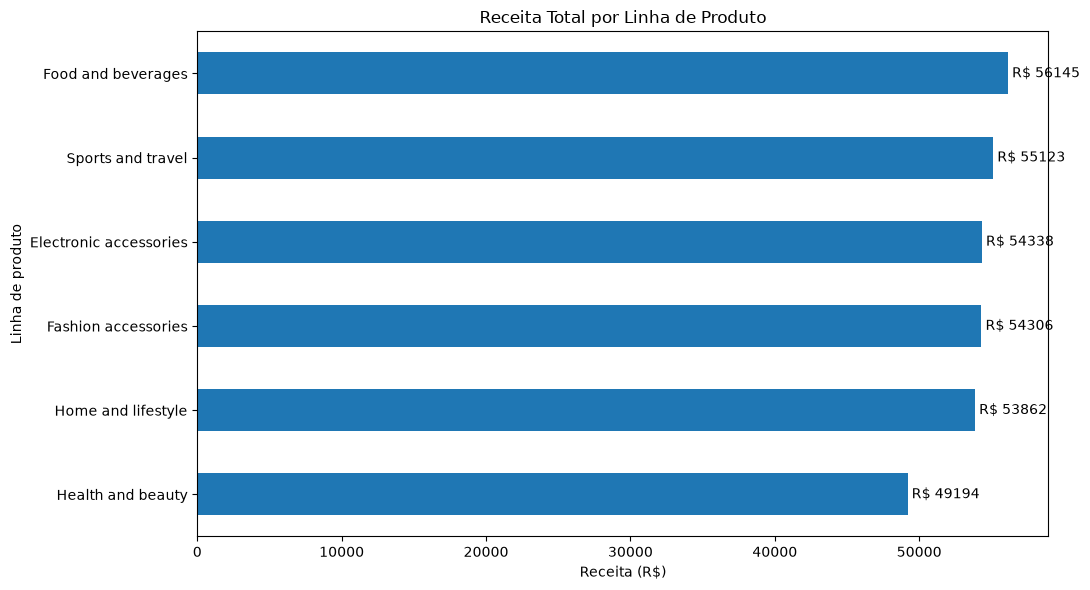

In [12]:
receita_por_produto = (
    df.groupby("linha_produto")["valor_total"]
    .sum()
    .sort_values(ascending=True)
)

display(
    receita_por_produto
    .sort_values(ascending=False)
    .to_frame("receita_total")
)

plt.figure(figsize=(11, 6))
ax = receita_por_produto.plot(kind="barh")
plt.title("Receita Total por Linha de Produto")
plt.xlabel("Receita (R$)")
plt.ylabel("Linha de produto")

for container in ax.containers:
    ax.bar_label(container, fmt="R$ %.0f", padding=3)

plt.tight_layout()
plt.show()


## Avaliação média por linha de produto

Aqui analisamos a percepção dos clientes em relação a cada linha de produto.


In [ ]:
avaliacao_por_produto = (
    df.groupby("linha_produto")["avaliacao"]
    .mean()
    .sort_values(ascending=True)
)

display(
    avaliacao_por_produto
    .sort_values(ascending=False)
    .to_frame("avaliacao_media")
)

plt.figure(figsize=(11, 6))
ax = avaliacao_por_produto.plot(kind="barh")
plt.title("Avaliação Média por Linha de Produto")
plt.xlabel("Avaliação média")
plt.ylabel("Linha de produto")
plt.xlim(0, 10)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

print(
    f"Melhor avaliação média: {avaliacao_por_produto.idxmax()} "
    f"— {avaliacao_por_produto.max():.2f}"
)


## Formas de pagamento

Esta análise mostra a quantidade de vendas realizadas por cada forma de pagamento.


,quantidade_vendas
forma_pagamento,
Ewallet,345
Cash,344
Credit card,311


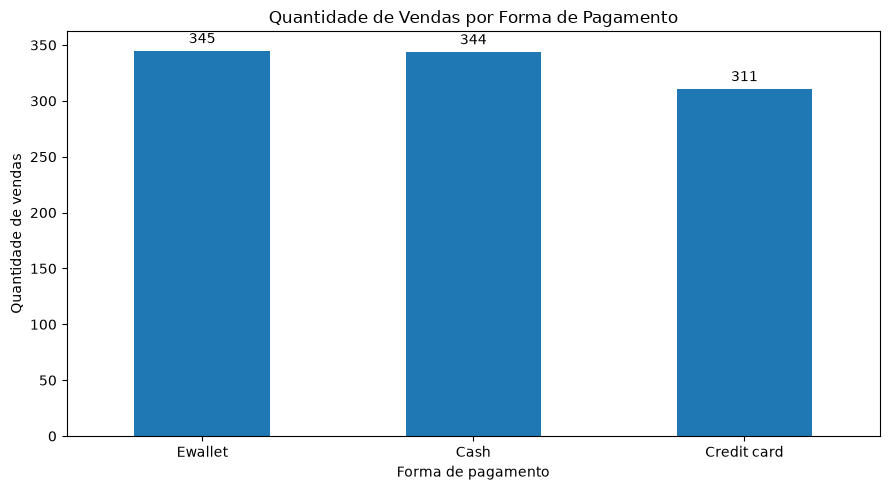

Forma de pagamento mais utilizada: Ewallet — 345 vendas


In [13]:
vendas_por_pagamento = (
    df.groupby("forma_pagamento")
    .size()
    .sort_values(ascending=False)
)

display(vendas_por_pagamento.to_frame("quantidade_vendas"))

plt.figure(figsize=(9, 5))
ax = vendas_por_pagamento.plot(kind="bar")
plt.title("Quantidade de Vendas por Forma de Pagamento")
plt.xlabel("Forma de pagamento")
plt.ylabel("Quantidade de vendas")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

print(
    f"Forma de pagamento mais utilizada: {vendas_por_pagamento.idxmax()} "
    f"— {vendas_por_pagamento.max()} vendas"
)


## Distribuição dos valores das vendas

O histograma permite observar a concentração dos valores das vendas e possíveis valores extremos.


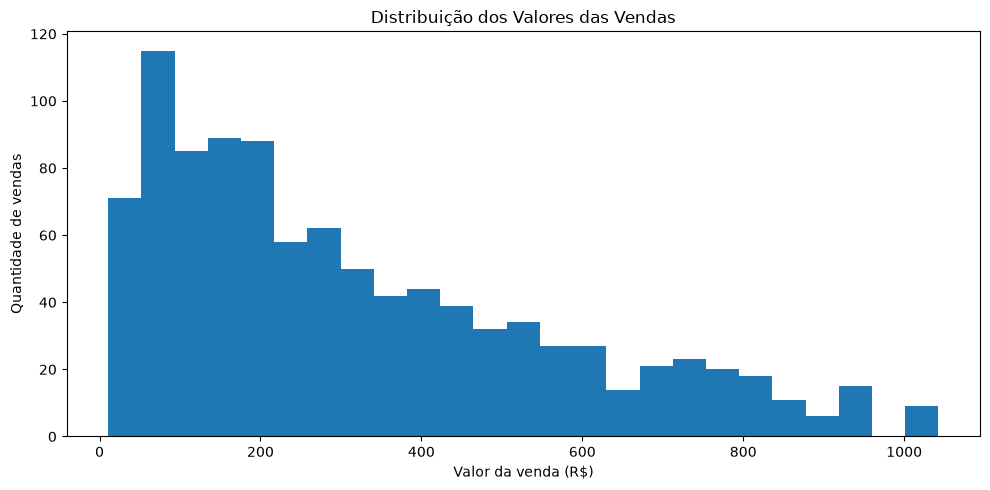

Valor médio: R$ 322.97
Valor mínimo: R$ 10.68
Valor máximo: R$ 1,042.65


In [14]:
plt.figure(figsize=(10, 5))
plt.hist(df["valor_total"].dropna(), bins=25)
plt.title("Distribuição dos Valores das Vendas")
plt.xlabel("Valor da venda (R$)")
plt.ylabel("Quantidade de vendas")
plt.tight_layout()
plt.show()

print(f"Valor médio: R$ {df['valor_total'].mean():,.2f}")
print(f"Valor mínimo: R$ {df['valor_total'].min():,.2f}")
print(f"Valor máximo: R$ {df['valor_total'].max():,.2f}")


## Dia da semana com mais vendas

A análise abaixo organiza os dias da semana em ordem cronológica, facilitando a identificação dos períodos de maior movimento.


,quantidade_vendas
dia_semana,
Monday,125
Tuesday,158
Wednesday,143
Thursday,138
Friday,139
Saturday,164
Sunday,133


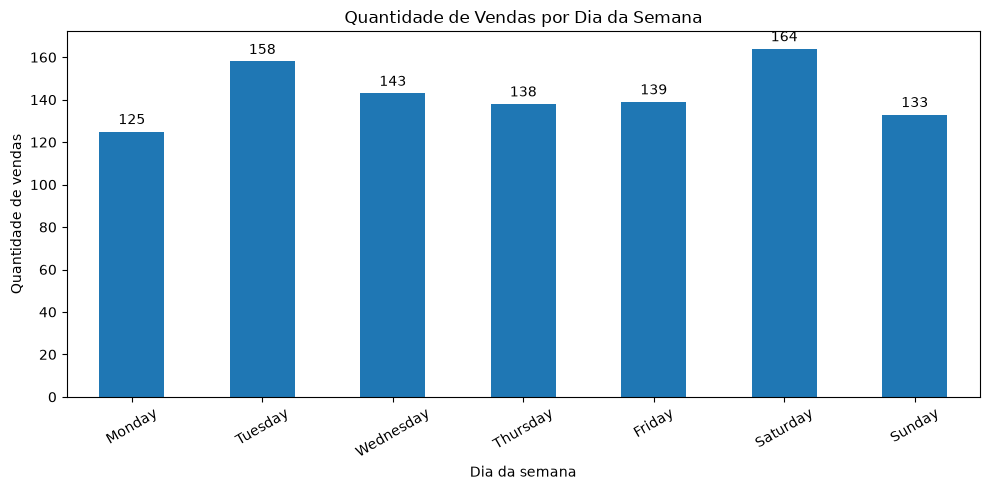

Dia com maior quantidade de vendas: Saturday — 164 vendas


In [15]:
vendas_por_dia = (
    df.groupby("dia_semana")
    .size()
    .reindex(ordem_dias)
)

display(vendas_por_dia.to_frame("quantidade_vendas"))

plt.figure(figsize=(10, 5))
ax = vendas_por_dia.plot(kind="bar")
plt.title("Quantidade de Vendas por Dia da Semana")
plt.xlabel("Dia da semana")
plt.ylabel("Quantidade de vendas")
plt.xticks(rotation=30)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

dia_mais_vendas = vendas_por_dia.idxmax()
qtd_dia_mais_vendas = vendas_por_dia.max()

print(
    f"Dia com maior quantidade de vendas: "
    f"{dia_mais_vendas} — {qtd_dia_mais_vendas} vendas"
)


## Maior venda registrada

Abaixo é apresentado o registro correspondente à maior venda da base.


In [16]:
maior_venda = df.loc[df["valor_total"].idxmax()]

maior_venda_resumo = pd.DataFrame({
    "Campo": [
        "ID da venda",
        "Filial",
        "Linha de produto",
        "Cidade",
        "Forma de pagamento",
        "Valor da venda"
    ],
    "Valor": [
        maior_venda["id_venda"],
        maior_venda["filial"],
        maior_venda["linha_produto"],
        maior_venda["cidade"],
        maior_venda["forma_pagamento"],
        f"R$ {maior_venda['valor_total']:,.2f}"
    ]
})

display(maior_venda_resumo)


,Campo,Valor
0,ID da venda,860-79-0874
1,Filial,Giza
2,Linha de produto,Fashion accessories
3,Cidade,Naypyitaw
4,Forma de pagamento,Credit card
5,Valor da venda,"R$ 1,042.65"


## Conclusões

A partir das análises realizadas, podemos destacar:

- A **filial com maior receita** é identificada pela soma de `valor_total`;
- A **filial com maior volume de vendas** é identificada pela quantidade de registros;
- A receita pode variar entre linhas de produto mesmo quando o volume de vendas é diferente;
- A avaliação média permite comparar a percepção dos clientes entre as categorias;
- A análise de pagamentos mostra o comportamento de compra dos clientes;
- A distribuição dos valores ajuda a identificar a concentração das vendas e valores extremos;
- A análise por dia da semana ajuda a identificar períodos de maior movimento.

### Principais indicadores



In [17]:
print(f"Receita total: R$ {receita_total:,.2f}")
print(f"Valor médio por venda: R$ {valor_medio:,.2f}")
print(f"Quantidade de vendas: {quantidade_vendas:,}")
print(f"Avaliação média: {avaliacao_media:.2f}")
print(f"Filial com maior receita: {maior_receita_filial}")
print(f"Filial com mais vendas: {maior_vendas_filial}")
print(f"Maior venda: R$ {maior_venda['valor_total']:,.2f}")
print(f"Dia com mais vendas: {dia_mais_vendas}")


Receita total: R$ 322,967.43
Valor médio por venda: R$ 322.97
Quantidade de vendas: 1,000
Avaliação média: 6.97
Filial com maior receita: Giza
Filial com mais vendas: Alex
Maior venda: R$ 1,042.65
Dia com mais vendas: Saturday
